True:      3.5 x + 1.2
Estimated: 3.500227572112982 x + 1.7031496282325223
Smallest residual: 0.0008863071257700916 at x = 0.53
Largest residual: 0.48862096134240485 at x = 0.25


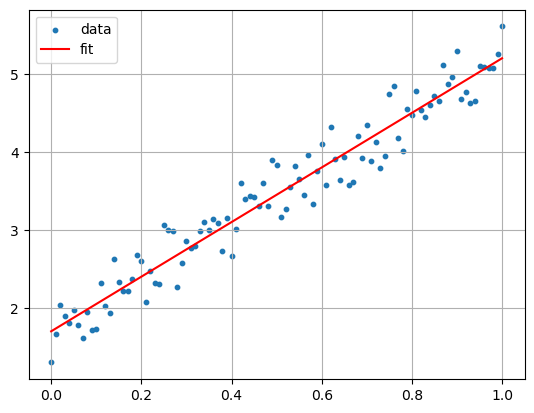

In [69]:
import numpy as np
import matplotlib.pyplot as plt

def inv(A):
    return np.linalg.inv(A)

def leastSquares(points):

    A = np.column_stack([np.ones(len(points)), points[:, :-1]])
    B = points[:, -1]
    
    coeffs = inv(A.T@A)@(A.T)@B
    
    #first element would be c1 and second element would be c2 where c1 is y-intercept and x2 is slope
    c1, c2 = coeffs

    return coeffs
    
# y = mx + b +/- random error
m, b = 3.5, 1.2
X = np.sort(np.arange(0, 1.01, 0.01))
Y = m * X + b + np.random.uniform(0, 1, size=len(X))

c1, c2 = leastSquares(np.column_stack([X, Y]))
residuals = Y - (c1 + c2 * X)

print("True:     ", m, "x +", b)
print("Estimated:", c2, "x +", c1)

sorted_idx = np.argsort(np.abs(residuals))
print("Smallest residual:", residuals[sorted_idx[0]],  "at x =", X[sorted_idx[0]])
print("Largest residual:",  residuals[sorted_idx[-1]], "at x =", X[sorted_idx[-1]])

plt.scatter(X, Y, s=10, label='data')
plt.plot(X, c1 + c2 * X, 'r', label='fit')
plt.legend()
plt.grid()
plt.show()